In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
def parse_improvement_file(filename):
    """Parse improvement file and return (times, objectives) arrays."""
    times = []
    objectives = []
    
    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                # Skip comments and empty lines
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        time = float(parts[0])
                        obj = float(parts[1])
                        times.append(time)
                        objectives.append(obj)
                    except ValueError:
                        continue
    except FileNotFoundError:
        print(f"Warning: File {filename} not found, skipping...")
        return None, None
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None
    
    if len(times) == 0:
        print(f"Warning: No data found in {filename}")
        return None, None
    
    return np.array(times), np.array(objectives)

In [ ]:
def plot_subgraph(instance_name, base_obj, ax, yscale_limit=2., xscale_limit=900):
    pdbo_file = f"./results/pdbo_xlogx/{instance_name}.txt"
    rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
    bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"

    pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
    rots_time, rots_obj = parse_improvement_file(rots_file)
    bma_time, bma_obj = parse_improvement_file(bma_file)
    
    pdbo_mask = pdbo_time <= xscale_limit
    rots_mask = rots_time <= xscale_limit
    bma_mask = bma_time <= xscale_limit

    pdbo_obj = pdbo_obj[pdbo_mask]
    rots_obj = rots_obj[rots_mask]
    bma_obj = bma_obj[bma_mask]

    # base_obj = min(bma_obj)

    pdbo_obj = np.minimum((pdbo_obj - base_obj) / base_obj, yscale_limit)
    rots_obj = np.minimum((rots_obj - base_obj) / base_obj, yscale_limit)
    bma_obj = np.minimum((bma_obj - base_obj) / base_obj, yscale_limit)
    print(min(pdbo_obj), min(rots_obj), min(bma_obj))

    pdbo_time = pdbo_time[pdbo_mask]
    rots_time = rots_time[rots_mask]
    bma_time = bma_time[bma_mask]
    
    
    colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
    # linestyles = ['-', '--', '-.', ':']

    ax.plot(pdbo_time, pdbo_obj, label="PDBO", 
                color=colors[0], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(pdbo_time)//50))

    ax.plot(rots_time, rots_obj, label="Ro-TS", 
                color=colors[1], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(rots_time)//50))

    ax.plot(bma_time, bma_obj, label="BMA", 
                color=colors[2], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(bma_time)//50))
    ax.set_xlabel('Time (s)', fontsize=12)
    
    # set y-tick to be percentages
    yticks = np.arange(0, yscale_limit+0.1, 0.25)
    yticklabels = [f"{int(y*100)}%" for y in yticks]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=10)
    # ax.set_ylim(0.9, yscale_limit+0.1)
    ax.set_ylim(-0.1, yscale_limit+0.1)
    ax.set_xlim(-20, xscale_limit)
    # ax.set_ylabel('Normalized Objective', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.set_title(f'{instance_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

In [19]:
n = 125
xscale_limit = 900
yscale_limit = 1.5

bks = pd.read_csv('taillarde_labels.txt', sep=' ', header=None, index_col=0, names=['instance', 'label'])

0.03596228758538926 0.12194433466945181 0.07644103201038785
0.03455138481950357 0.08778815854939466 0.02869146995411576
0.07725096727654272 0.15214112400813168 0.10964653419896386
0.05585781646717446 0.4045460041107484 0.05857816467174465
0.048212846009137326 0.07616232195646332 0.04713786616500941


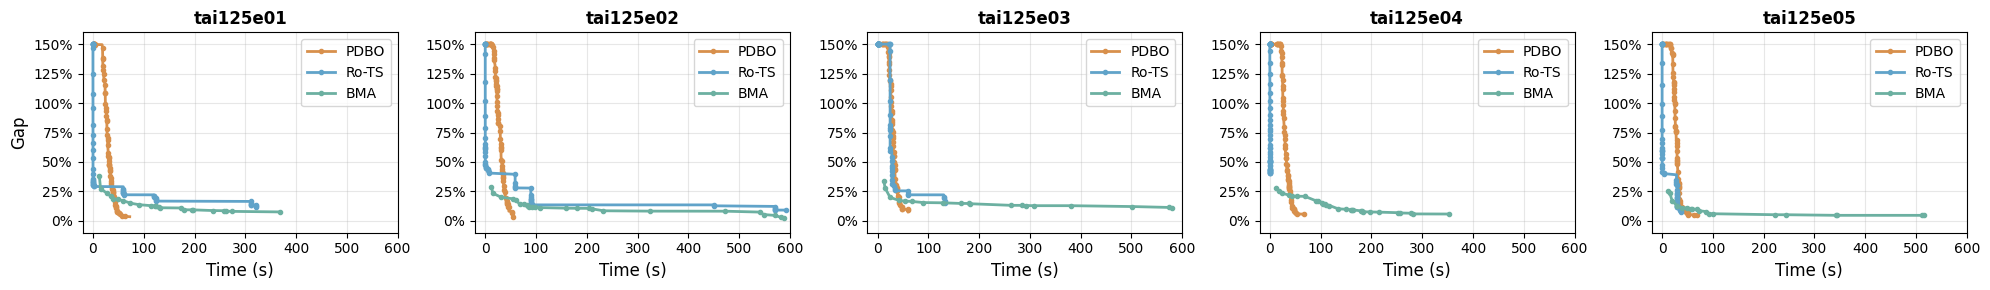

0.10024330900243308 0.13694820994091067 0.08738269030239833
0.057313909399321496 0.31993614049091995 0.15589702654160847
0.03168831168831169 1.5 0.14115027829313542
0.11970338983050847 1.5 0.052701271186440676
0.0812335013198944 0.24270058395328373 0.14034877209823216


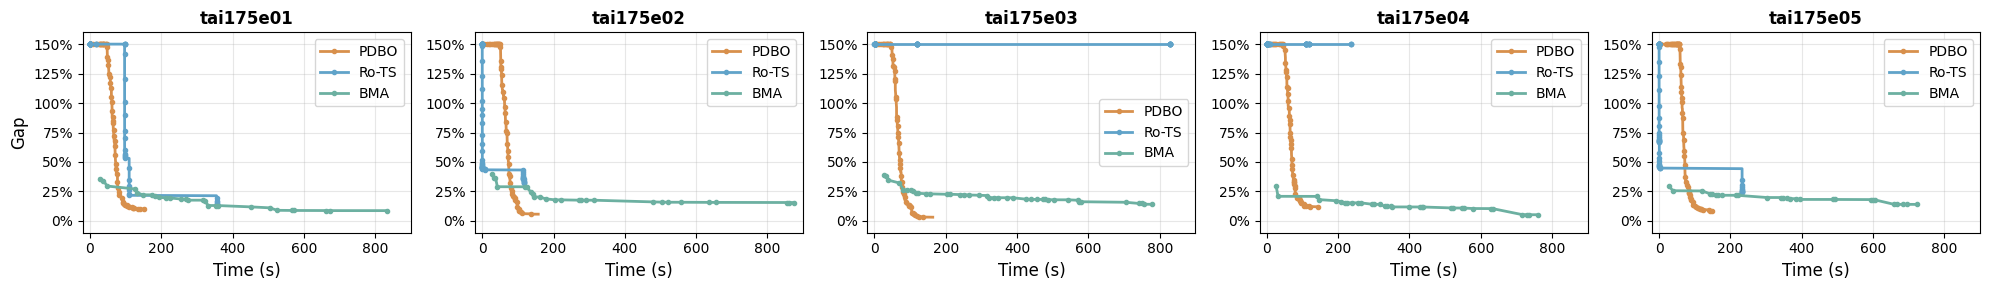

0.04882025976972378 0.2565084226646248 0.1902047529918893
0.05174177569590265 0.235624293329026 0.1828595272707694
0.03994595051093658 0.2448554457675309 0.1715508262252625
0.05470496711687565 1.3649569185309154 0.16461174378620086
0.04958523225556019 1.5 0.18098825423753181


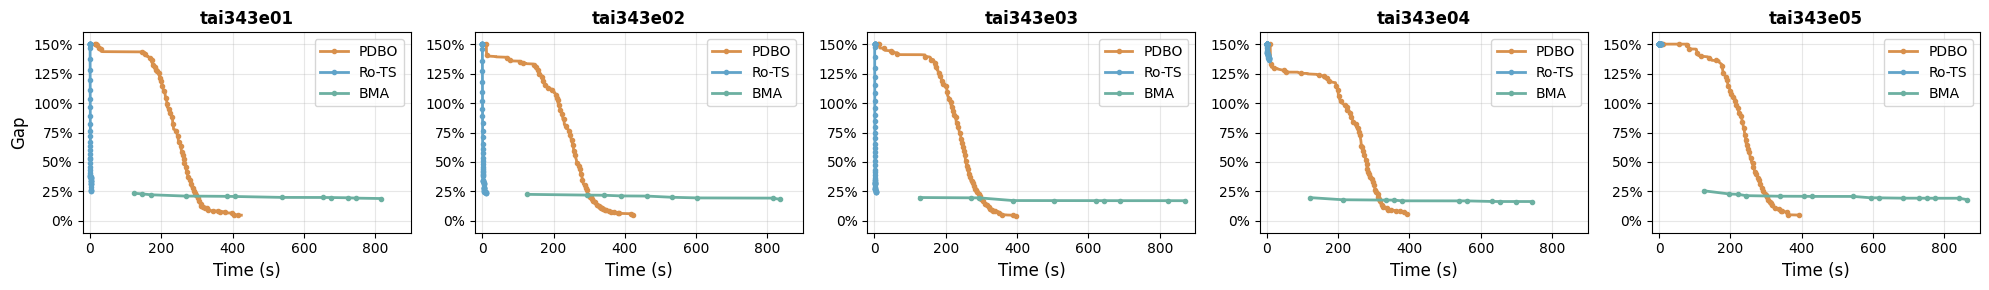

0.06969201941094508 1.1220150867246432 0.1991687887378081
0.06583997917504793 1.1626476086802187 0.1964881558085051
0.04212797898292363 0.22904958963368263 0.19356352036029273
0.055808771887336225 1.1894650165895715 0.18987672858492166
0.061753321627298345 1.1699639728432747 0.21976565602438172


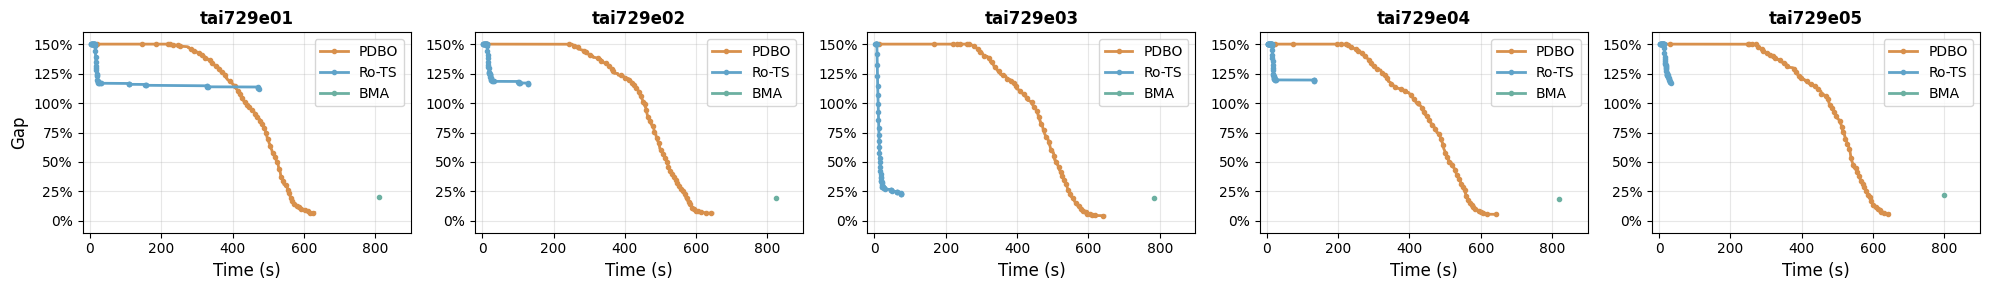

In [20]:
for n in [125, 175, 343, 729]:
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 3))

    for i, ax in enumerate(axes):
        instance_name = f"tai{n}e0{i+1}"
        if n == 125:
            xscale_limit = 600
        else:
            xscale_limit = 900
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if i == 0 :
            ax.set_ylabel('Gap', fontsize=12)
            

    plt.tight_layout()
    plt.savefig(f'comparison_tai{n}e.pdf', dpi=800, bbox_inches='tight')
    plt.show()

0.03596228758538926 0.16829447298594252 0.08112685598148253
0.10024330900243308 0.13694820994091067 0.08738269030239833
0.04882025976972378 0.2565084226646248 0.1902047529918893
0.06969201941094508 1.1220150867246432 0.1991687887378081
0.03455138481950357 0.13627066172812205 0.0861849742937697
0.057313909399321496 0.31993614049091995 0.15589702654160847
0.05174177569590265 0.235624293329026 0.1828595272707694
0.06583997917504793 1.1626476086802187 0.1964881558085051
0.07725096727654272 0.15214112400813168 0.13089382910354777
0.03168831168831169 1.5 0.14115027829313542
0.03994595051093658 0.2448554457675309 0.1715508262252625
0.04212797898292363 0.22904958963368263 0.19356352036029273
0.05585781646717446 0.4045460041107484 0.05954539958892516
0.11970338983050847 1.5 0.052701271186440676
0.05470496711687565 1.3649569185309154 0.16461174378620086
0.055808771887336225 1.1894650165895715 0.18987672858492166
0.048212846009137326 0.07616232195646332 0.05262026337006181
0.0812335013198944 0.24

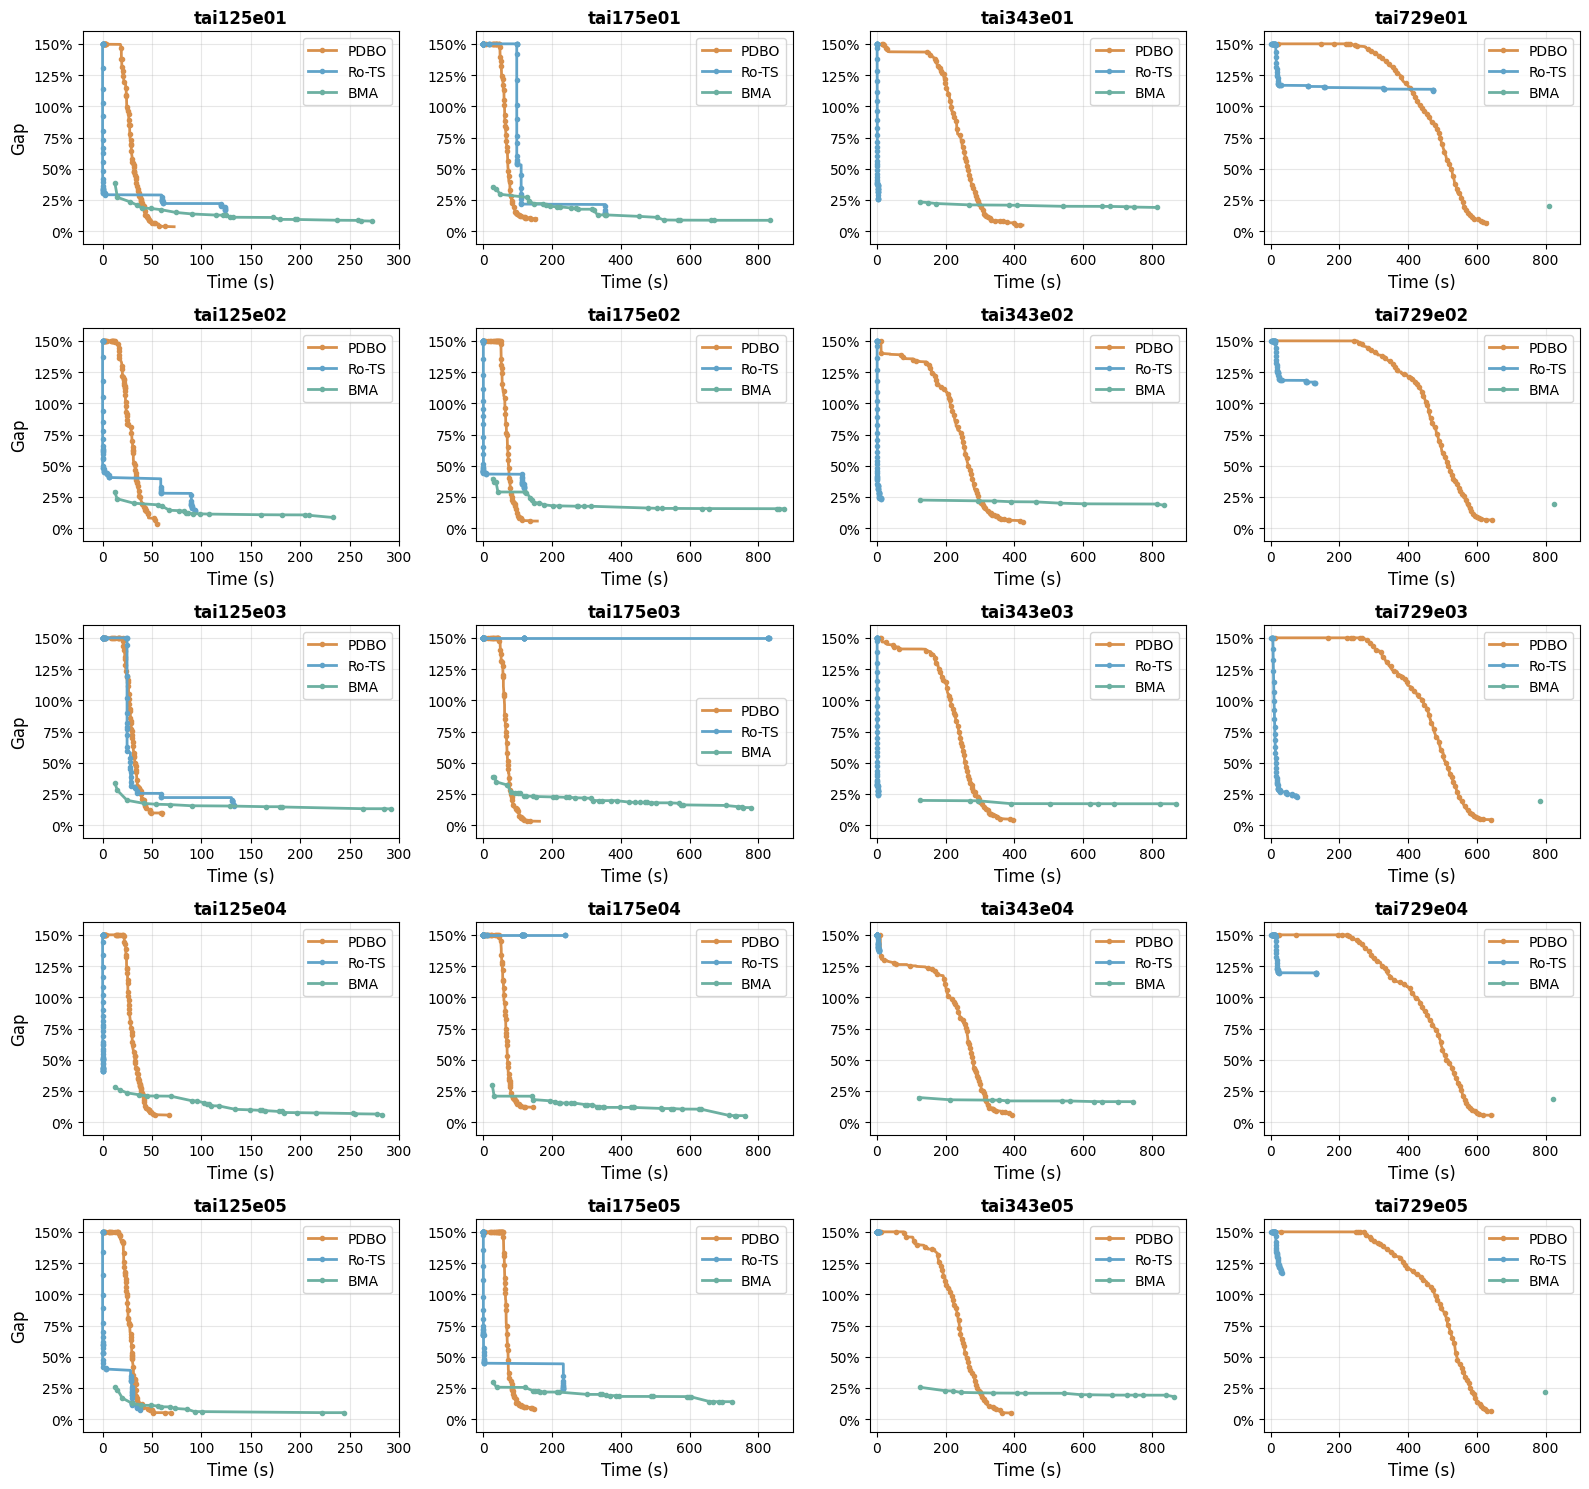

In [21]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(16, 15))

for i in range(5):
    for j in range(4):
        n = [125, 175, 343, 729][j]
        ax = axes[i, j]
        instance_name = f"tai{n}e0{i+1}"
        if n == 125:
            xscale_limit = 300
        else:
            xscale_limit = 900
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if j == 0 :
            ax.set_ylabel('Gap', fontsize=12)
# for n in [125, 175, 343, 729]:
    

#     for i, ax in enumerate(axes):
#         instance_name = f"tai{n}e0{i+1}"
#         plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
#         if i == 0 :
#             ax.set_ylabel('Gap', fontsize=12)
            

plt.tight_layout()
plt.savefig(f'comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()

In [22]:
instance_name = "tai175e05"

pdbo_file = f"./results/pdbo/{instance_name}.txt"
rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"


pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
rots_time, rots_obj = parse_improvement_file(rots_file)
bma_time, bma_obj = parse_improvement_file(bma_file)

In [23]:
yscale_limit = 2.5
xscale_limit = 900

pdbo_mask = pdbo_time <= xscale_limit
rots_mask = rots_time <= xscale_limit
bma_mask = bma_time <= xscale_limit

pdbo_obj = pdbo_obj[pdbo_mask]
rots_obj = rots_obj[rots_mask]
bma_obj = bma_obj[bma_mask]

base_obj = min(bma_obj)

pdbo_obj = np.minimum(pdbo_obj / base_obj, yscale_limit)
rots_obj = np.minimum(rots_obj / base_obj, yscale_limit)
bma_obj = np.minimum(bma_obj / base_obj, yscale_limit)

pdbo_time = pdbo_time[pdbo_mask]
rots_time = rots_time[rots_mask]
bma_time = bma_time[bma_mask]

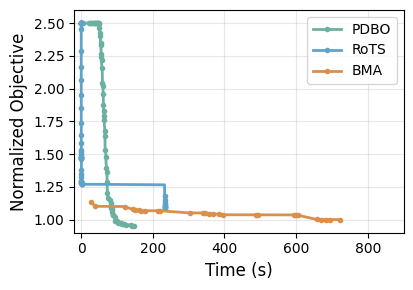

In [24]:
plt.figure(figsize=(4, 3))
colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
# linestyles = ['-', '--', '-.', ':']

plt.plot(pdbo_time, pdbo_obj, label="PDBO", 
            color=colors[0], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(pdbo_time)//50))

plt.plot(rots_time, rots_obj, label="RoTS", 
            color=colors[1], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(rots_time)//50))

plt.plot(bma_time, bma_obj, label="BMA", 
            color=colors[2], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(bma_time)//50))
plt.xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.ylim(0.9, 2.6)
plt.xlim(-20, 900)
plt.ylabel('Normalized Objective', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

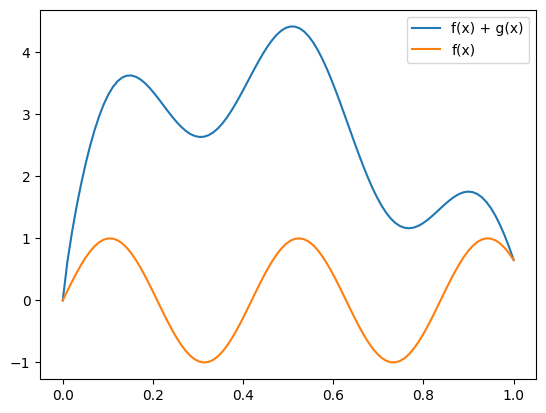

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# plot three methods side by side for comparison
def g(x):
    return x * np.log(x)

def f(x):
    return np.sin(x*15)

# plot the function f(x) from 0 to 1
x = np.linspace(1e-6, 1, 100)
y = -10*g(x) + f(x)
plt.plot(x, y, label="f(x) + g(x)")
plt.plot(x, f(x), label="f(x)")
plt.legend()